In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud


---
## **Load  Dataset**

In [2]:
df=pd.read_csv('D:\\Github\\PRODIGY_DS_04\\data\\twitter_training.csv')
df.columns = ['id', 'topic', 'sentiment', 'text']
df.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


---
## **Data Understanding**

In [3]:
df.shape,df.info(),df.describe(),df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74681 non-null  int64 
 1   topic      74681 non-null  object
 2   sentiment  74681 non-null  object
 3   text       73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


((74681, 4),
 None,
                  id
 count  74681.000000
 mean    6432.640149
 std     3740.423819
 min        1.000000
 25%     3195.000000
 50%     6422.000000
 75%     9601.000000
 max    13200.000000,
          id        topic sentiment  \
 0      2401  Borderlands  Positive   
 1      2401  Borderlands  Positive   
 2      2401  Borderlands  Positive   
 3      2401  Borderlands  Positive   
 4      2401  Borderlands  Positive   
 ...     ...          ...       ...   
 74676  9200       Nvidia  Positive   
 74677  9200       Nvidia  Positive   
 74678  9200       Nvidia  Positive   
 74679  9200       Nvidia  Positive   
 74680  9200       Nvidia  Positive   
 
                                                     text  
 0      I am coming to the borders and I will kill you...  
 1      im getting on borderlands and i will kill you ...  
 2      im coming on borderlands and i will murder you...  
 3      im getting on borderlands 2 and i will murder ...  
 4      im getting i

In [4]:
df.select_dtypes(include='number').columns.to_list()

['id']

In [5]:
df.select_dtypes(include='object').columns.to_list()


['topic', 'sentiment', 'text']

In [6]:
df.sample(10,random_state=42)

,id,topic,sentiment,text
34877,6792,Fortnite,Irrelevant,went to go in george's room to find his door w...
21704,4115,CS-GO,Positive,Yo this looks LIT! Team:GO/Overwatch combo
47008,5665,HomeDepot,Negative,Pay attention executive administrators. While ...
7969,9369,Overwatch,Irrelevant,Guy looked at me and says my name was put on t...
454,2476,Borderlands,Positive,one
58076,11558,TomClancysRainbowSix,Negative,@Rainbow6Game Server are Available in Xbox 🥺
39653,1208,Battlefield,Irrelevant,A ban for Battlefield 4 player lIlColdllI has ...
51601,10458,RedDeadRedemption(RDR),Irrelevant,lmao gason might kill me for this
23819,4482,Google,Irrelevant,pls google the definitions of words before usi...
62213,5065,GrandTheftAuto(GTA),Irrelevant,After them cops ran a crowd of peaceful protes...


In [7]:
df[df['text'].str.strip()==''].sum()



id                                                     1156176
topic        CallOfDutyBlackopsColdWarCallOfDutyBlackopsCol...
sentiment    IrrelevantPositiveNeutralNegativeNegativeNeutr...
text                                                       ...
dtype: object

In [8]:

df['text'].str.contains('http').sum()
df['text'].apply(lambda x: bool(re.search(r'http\S+', str(x)))).sum()

np.int64(2430)

In [9]:
df['text'].str.contains('@').sum()

18309

In [10]:
df['text'].str.contains('#').sum()

35

In [11]:
df['text'].apply(lambda x: any(char in str(x) for char in ['😀','😂','🔥','❤️'])).sum()

np.int64(0)

In [12]:
df['text'].apply(lambda x: bool(re.search(r'[^a-zA-Z0-9\s]', str(x)))).sum()

np.int64(64669)

In [13]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df[df['text_length'] < 3]


,id,topic,sentiment,text,text_length
10,2402,Borderlands,Positive,was,1
52,2409,Borderlands,Neutral,all,1
60,2411,Borderlands,Neutral,NaN,1
61,2411,Borderlands,Neutral,.. [,2
62,2411,Borderlands,Neutral,.. 45,2
...,...,...,...,...,...
74527,9175,Nvidia,Neutral,What next?,2
74590,9185,Nvidia,Neutral,you,1
74596,9186,Nvidia,Positive,from,1
74620,9190,Nvidia,Positive,were,1


---
## **Data Cleaning**

### Remove Empty Text and Null values

In [14]:
df.isna().sum()


id               0
topic            0
sentiment        0
text           686
text_length      0
dtype: int64

In [15]:
df=df.dropna(subset=['text'])
df=df[df['text'].str.strip()!='']
df[df['text'].str.strip()==''].sum()
df.isna().sum()

id             0
topic          0
sentiment      0
text           0
text_length    0
dtype: int64

### Remove Duplicates

In [16]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### Remove Short Text

In [17]:
df=df[df['text_length'] >= 3]

### Convert Text into lower case

In [18]:
df['text']=df['text'].str.lower()

### Remove URLs, Mentions(@), Hash(#), Numbers, Punctions, Extra Whitespaces

In [19]:
df['text'] = df['text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'@\w+', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'#', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'\d+', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [20]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [21]:

nltk.download('punkt_tab')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Remove Stopwords + Lemmatization

In [22]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    text = str(text)  # ensure string
    tokens = word_tokenize(text)
    filtered_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    return " ".join(filtered_tokens)

df['clean_text'] = df['text'].apply(clean_and_lemmatize)

In [23]:
df[['text', 'clean_text']].sample(5)

,text,clean_text
42236,i have heard about an app related games in tha...,heard app related game app prize pool say play...
65033,fuckk the lgbt faction at ea those are the one...,fuckk lgbt faction ea one benefit without ever...
47973,i am not begging for the home depot to close i...,begging home depot close store since late dad ...
12899,ight false alarm pictwittercomfgbubvkb,ight false alarm pictwittercomfgbubvkb
4934,thanks for submitting grand summoners watch th...,thanks submitting grand summoners watch video ...


---
## **Exploratory Data Analysis**

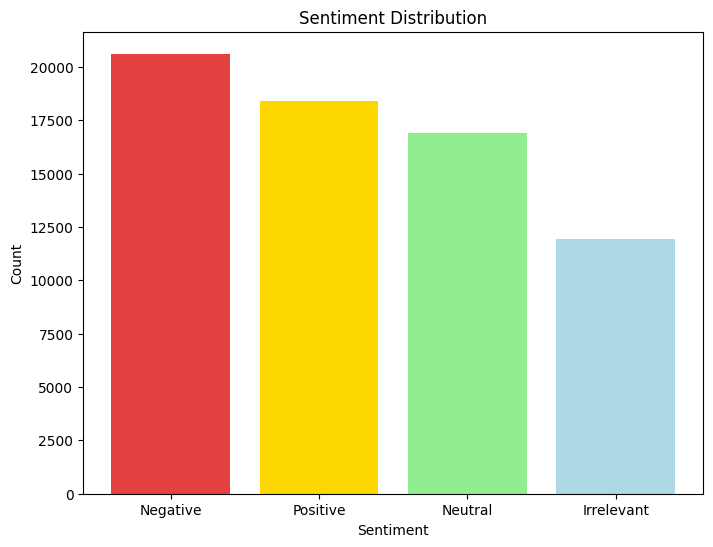

In [24]:
sentiment_data=df['sentiment'].value_counts().reset_index()
plt.figure(figsize=(8,6))
plt.bar(sentiment_data['sentiment'],sentiment_data['count'],color=[ "#e44242",'gold','lightgreen','lightblue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Insight : 30% negative seniments, 26% Positive , 24% Neutral and 17% Irrelevant sentiments
# Dataset is not that imbalance

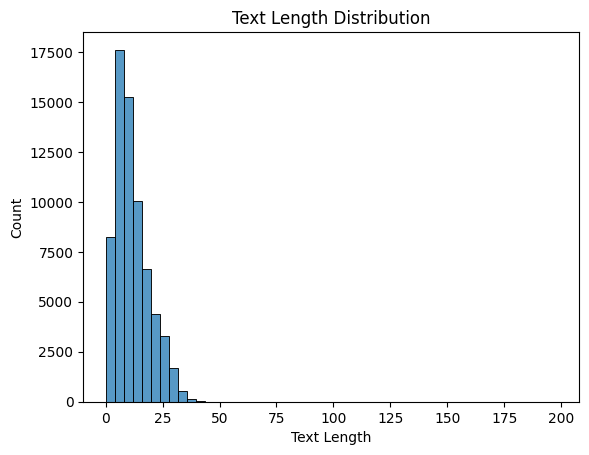

In [25]:
df['text_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['text_length'],bins=50)
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.show()

# Insight : Mostly text length lies between  5-25

C:\Users\Professor\AppData\Local\Temp\ipykernel_10452\410946507.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_df,x='Frequency',y='Word',palette='magma')


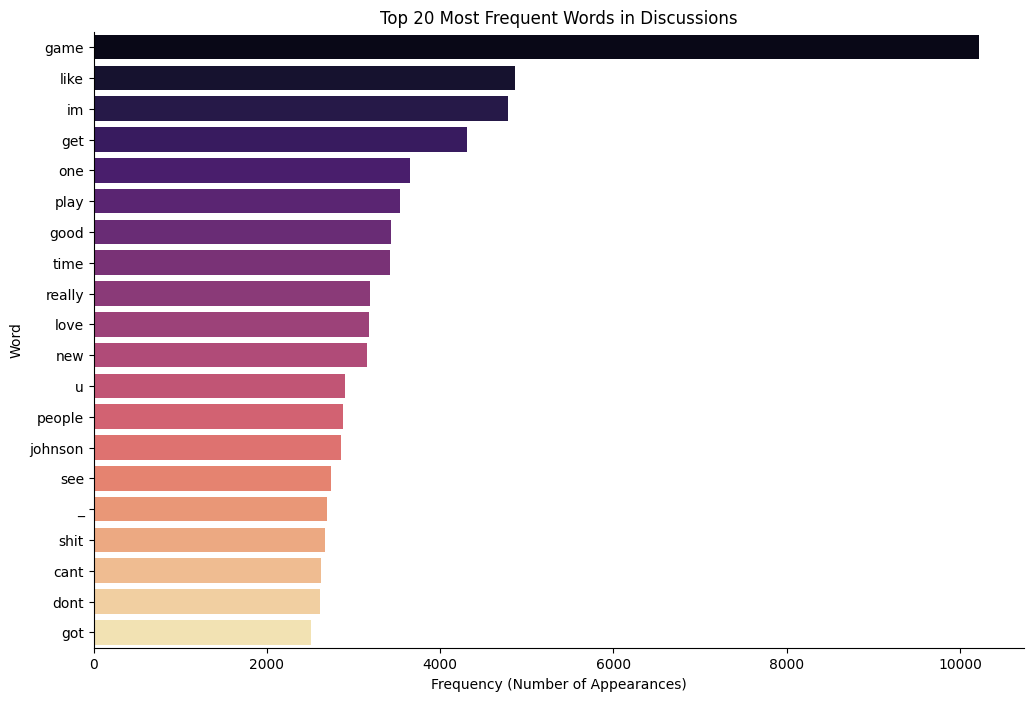

In [ ]:
all_text=' '.join(df['clean_text'].dropna().astype(str))
word_counts=Counter(all_text.split())
top_20_words=word_counts.most_common(20)
plt.figure(figsize=(12, 8))
top_words_df=pd.DataFrame(top_20_words,columns=['Word','Frequency'])
sns.barplot(data=top_words_df,x='Frequency',y='Word',palette='magma')
plt.title('Top 20 Most Frequent Words in Discussions')
plt.xlabel('Frequency (Number of Appearances)')
plt.ylabel('Word')
sns.despine()
plt.show()

# Insight: game is the most discussed topic 

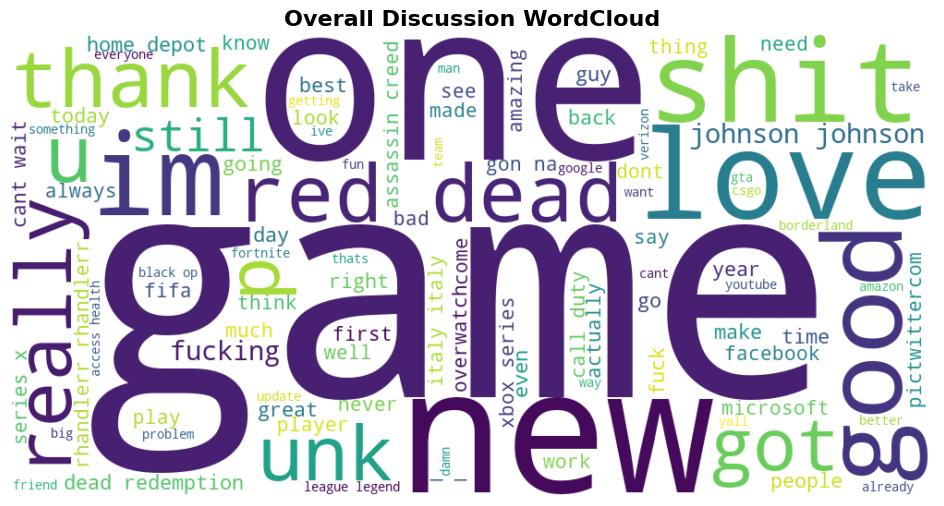

In [ ]:
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    colormap='viridis',      
    max_words=100,           
    random_state=42          
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Discussion WordCloud', fontsize=16, weight='bold')
plt.show()

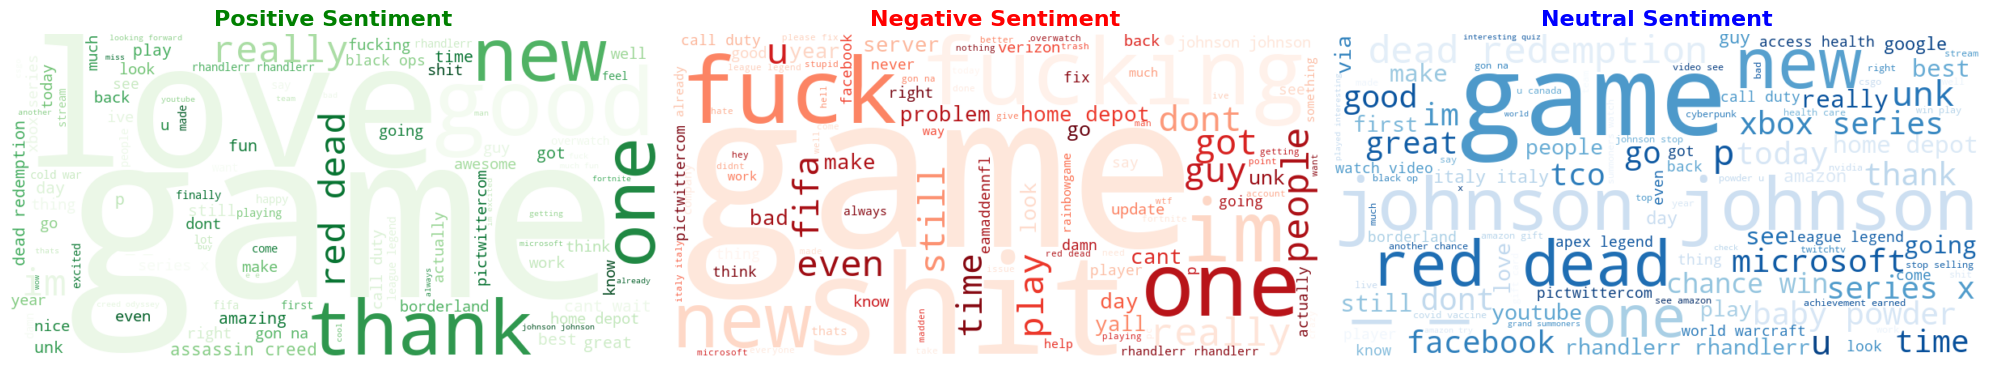

In [ ]:



def generate_cloud(text_data, colormap):

    combined_text = ' '.join(text_data.dropna().astype(str))
    
    
    return WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        colormap=colormap, 
        max_words=100,
        random_state=42
    ).generate(combined_text)


text_positive = df[df['sentiment'] == 'Positive']['clean_text']
text_negative = df[df['sentiment'] == 'Negative']['clean_text']
text_neutral = df[df['sentiment'] == 'Neutral']['clean_text']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Positive WordCloud ---
cloud_pos = generate_cloud(text_positive, 'Greens') # Green theme for positive
axes[0].imshow(cloud_pos, interpolation='bilinear')
axes[0].set_title('Positive Sentiment', fontsize=16, weight='bold', color='green')
axes[0].axis('off')

# --- Negative WordCloud ---
cloud_neg = generate_cloud(text_negative, 'Reds') # Red theme for negative
axes[1].imshow(cloud_neg, interpolation='bilinear')
axes[1].set_title('Negative Sentiment', fontsize=16, weight='bold', color='red')
axes[1].axis('off')

# --- Neutral WordCloud ---
cloud_neu = generate_cloud(text_neutral, 'Blues') # Blue theme for neutral
axes[2].imshow(cloud_neu, interpolation='bilinear')
axes[2].set_title('Neutral Sentiment', fontsize=16, weight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Insight: Postivie Sentiment Defines by : 'Thank'
# Insight: Negative Sentiment Defines by : 'fuck'


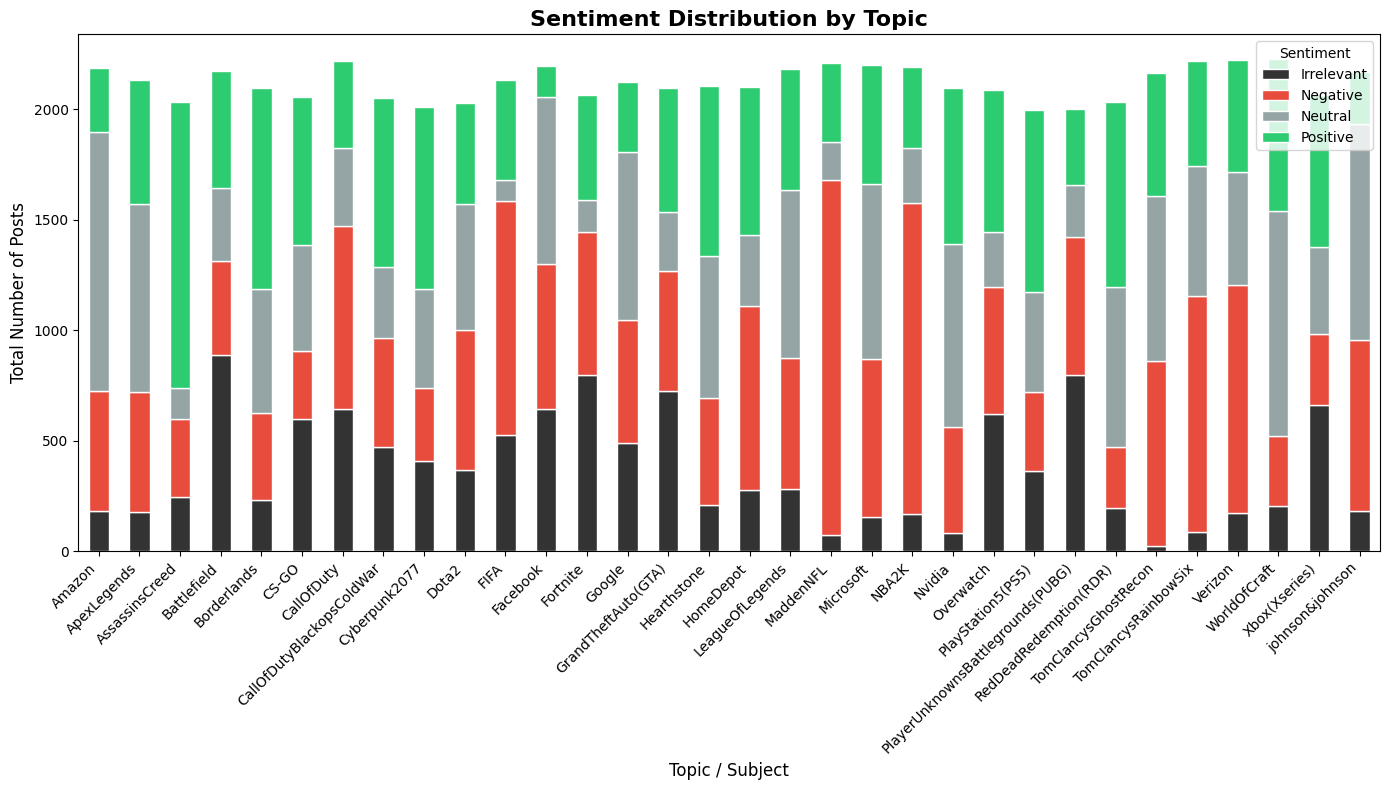

--- INSIGHTS ---
 Topic with the most Negative reactions: MaddenNFL
 Topic with the most Positive reactions: AssassinsCreed


In [36]:
topic_sentiment = df.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
plot_colors = [colors.get(col, '#333333') for col in topic_sentiment.columns]
topic_sentiment.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8), 
    color=plot_colors,
    edgecolor='white' 
)
plt.title('Sentiment Distribution by Topic', fontsize=16, weight='bold')
plt.xlabel('Topic / Subject', fontsize=12)
plt.ylabel('Total Number of Posts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()

print("--- INSIGHTS ---")
if 'Negative' in topic_sentiment.columns:
    most_negative = topic_sentiment['Negative'].idxmax()
    print(f" Topic with the most Negative reactions: {most_negative}")

if 'Positive' in topic_sentiment.columns:
    most_positive = topic_sentiment['Positive'].idxmax()
    print(f" Topic with the most Positive reactions: {most_positive}")

C:\Users\Professor\AppData\Local\Temp\ipykernel_10452\4138833114.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Professor\AppData\Local\Temp\ipykernel_10452\4138833114.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Professor\AppData\Local\Temp\ipykernel_10452\4138833114.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Professor\AppData\Local\Temp\ipykernel_10452\4138833114.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y

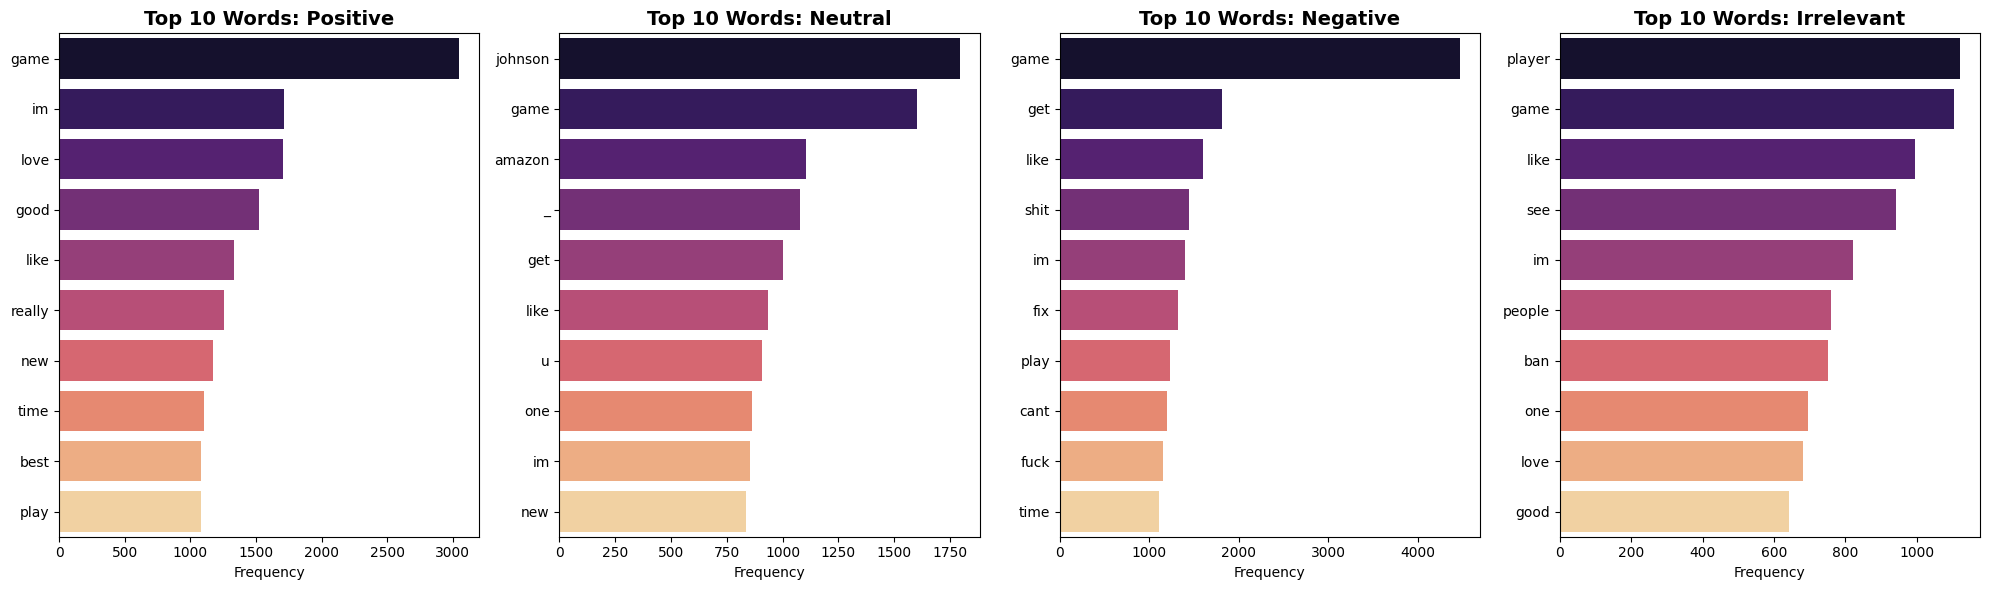

--- Emotional Vocabulary Extracted ---
Positive: ['game', 'im', 'love', 'good', 'like', 'really', 'new', 'time', 'best', 'play']
Neutral: ['johnson', 'game', 'amazon', '_', 'get', 'like', 'u', 'one', 'im', 'new']
Negative: ['game', 'get', 'like', 'shit', 'im', 'fix', 'play', 'cant', 'fuck', 'time']
Irrelevant: ['player', 'game', 'like', 'see', 'im', 'people', 'ban', 'one', 'love', 'good']


In [ ]:
sentiments = df['sentiment'].dropna().unique()
fig, axes = plt.subplots(1, len(sentiments), figsize=(5 * len(sentiments), 6))

for i, sentiment in enumerate(sentiments):
    text_data = df[df['sentiment'] == sentiment]['clean_text'].dropna().astype(str)
    combined_text = ' '.join(text_data)
    word_counts = Counter(combined_text.split())
    top_10_words = word_counts.most_common(10)
    top_df = pd.DataFrame(top_10_words, columns=['Word', 'Frequency'])
    sns.barplot(
        data=top_df, 
        x='Frequency', 
        y='Word', 
        ax=axes[i], 
        palette='magma'
    )
    axes[i].set_title(f'Top 10 Words: {sentiment}', fontsize=14, weight='bold')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel('') 
plt.tight_layout()
plt.show()
print("--- Emotional Vocabulary Extracted ---")
for sentiment in sentiments:
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_text'].dropna().astype(str))
    top_10 = [word for word, count in Counter(text.split()).most_common(10)]
    print(f"{sentiment}: {top_10}")

---
# 📊  Exploratory Data Analysis (Polished Version)

## 🧹 Data Quality Observations

* **686 null values** were found in the `text` column and handled appropriately.
* **2,340 duplicate rows** were detected and removed to ensure data integrity.

---

## 📈 Sentiment Distribution

* **30% Negative**
* **26% Positive**
* **24% Neutral**
* **17% Irrelevant**

The dataset shows a relatively balanced distribution across sentiment categories, with a slight dominance of negative sentiment. Overall, the dataset is not heavily imbalanced.

---

## 📝 Text Length Analysis

* Most posts contain **5–25 words**, indicating short, concise social media expressions.
* This aligns with typical social media behavior where users share brief opinions.

---

## 🎮 Topic Insights

* **"Game"** is the most frequently occurring word, confirming that discussions are primarily centered around gaming topics.

### 📌 Sentiment by Topic:

* **Most Negative Reactions:** *MaddenNFL*
* **Most Positive Reactions:** *AssassinsCreed*

This suggests stronger dissatisfaction around MaddenNFL-related discussions, while Assassin’s Creed generates comparatively more favorable engagement.

---

## 💬 Emotional Vocabulary Analysis

### 🔹 Positive Sentiment Vocabulary

* Frequently associated words:
  `game`, `love`, `good`, `best`, `play`, `really`, `new`
* The word **“thank”** appears as a defining positive indicator.
* Positive posts emphasize enjoyment, appreciation, and satisfaction.

---

### 🔹 Neutral Sentiment Vocabulary

* Common words:
  `game`, `amazon`, `johnson`, `new`, `one`
* Neutral posts often reflect informational or general discussions rather than strong emotional reactions.

---

### 🔹 Negative Sentiment Vocabulary

* Frequently used words:
  `shit`, `fuck`, `cant`, `fix`
* Negative sentiment is strongly characterized by frustration-related terms.
* Indicates dissatisfaction, complaints, and technical issues.

---

### 🔹 Irrelevant Sentiment Vocabulary

* Common words:
  `player`, `people`, `see`, `ban`
* These posts appear less emotionally driven and may not directly reflect opinions about the topic.

---

# 🎯 Key Overall Insights

1. Sentiment distribution is moderately balanced, though negative reactions slightly dominate.
2. Gaming discussions are the central theme across the dataset.
3. Emotional vocabulary clearly differentiates positive (gratitude, enjoyment) and negative (frustration, profanity) reactions.
4. MaddenNFL receives the highest volume of negative sentiment.
5. Assassin’s Creed generates the most positive engagement.
6. Social media posts are generally short and direct (5–25 words).

---

